# k-Nearest Neighbor (kNN) exercise 4b - CIFAR-10 Dataset

*Complete and hand in this completed worksheet.*

The kNN classifier consists of two stages:

- During training, the classifier takes the training data and simply remembers it
- During testing, kNN classifies every test image by comparing to all training images and transfering the labels of the k most similar training examples
- In this exercise, the ultimate goal is to find an optimal value of hyper-parameter k through a cross-validation procedure.

In this exercise you will implement these steps and gain proficiency in writing efficient, vectorized code.

In [87]:
# Run some setup code for this notebook.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import os

# This is a bit of magic to make matplotlib figures appear inline in the notebook
# rather than in a new window. Also setting some parameters for display.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 10.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


In [88]:
#each batch file is a pickled dict with:
#- 'data' uint 8 array of shape (10000,3072). the first 1024 values are the red channel, the next 1024 the green channel and the last 1024 the blue one (row-amjor 32x32)
#- 'labels' list of 10000 integer in 0-9

def load_CIFAR_batch(filename):
    with open(filename, 'rb') as f:
        datadict = pickle.load(f,encoding='latin1')
        X=datadict['data']
        Y=datadict['labels']

        #(N,3072) -> (N,3,32,32) -> (N,32,32,3) to get the shape of the actual colour image
        #convert to float. with uint8 the squared diff in the L2 distance would overflow

        X=X.reshape(-1,3,32,32).transpose(0,2,3,1).astype('float64')
        Y = np.array(Y)
        return X,Y

def load_CIFAR10(root):
    xs=[]
    ys=[]
    for b in range(1,6):
        X,Y = load_CIFAR_batch(os.path.join(root,'data_batch_%d'%b))
        xs.append(X)
        ys.append(Y)
    Xtr = np.concatenate(xs)
    Ytr = np.concatenate(ys)
    Xte, Yte = load_CIFAR_batch(os.path.join(root,'test_batch'))
    return Xtr, Ytr, Xte, Yte

In [89]:
# Load the raw CIFAR-10 data.
cifar10dir = 'cifar-10'
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


**Inline Question #1:** Notice the outputs of the shape attributes for the numpy arrays downloaded.

- What are the ranks of the arrays for the training data and test data? (1)
- Are the shapes coherent from the description of the dataset that we can find [here](http://yann.lecun.com/exdb/mnist/)? Explain the different dimensions of the 4 arrays in cell above. (2)

**Your Answer**:
1) The rank of an array is its nbr of dimensions. Here X_train and X_test have rank 4, while y_train and y_test have rank 1. X_train.shape = (50000, 32, 32, 3) contains 4 nbrs, so the array has a rank of 4 (one more dimension than for MNIST / Fashion-MNIST because of the colour channels). We can check this directly with X_train.ndim:


In [90]:
X_train.ndim

4

2) The CIFAR-10 dataset consists of 60'000 32x32 colour images in 10 classes (0 = airplane, 1 = automobile, 2 = bird, 3 = cat, 4 = deer, 5 = dog, 6 = frog, 7 = horse, 8 = ship, 9 = truck), with 6'000 images per class. There are 50'000 training images, stored in 5 files (data_batch_1 to data_batch_5) of 10'000 images each, and 10'000 test images (test_batch). Each image is stored as a row of 3072 values (1024 red, 1024 green, 1024 blue); in our loading function we reshape it into the actual image shape (32, 32, 3). The shapes we obtained are coherent with this description:
- X_train (50000,32,32,3) = 50'000 training images, each with 32 rows x 32 columns of pxls and 3 colour channels (RGB)
- y_train (50000,) = one label (0-9) for each training image
- X_test (10000,32,32,3) = 10'000 test images, each with 32 rows x 32 columns of pxls and 3 colour channels (RGB)
- y_test (10000,) = one label (0-9) for each test image

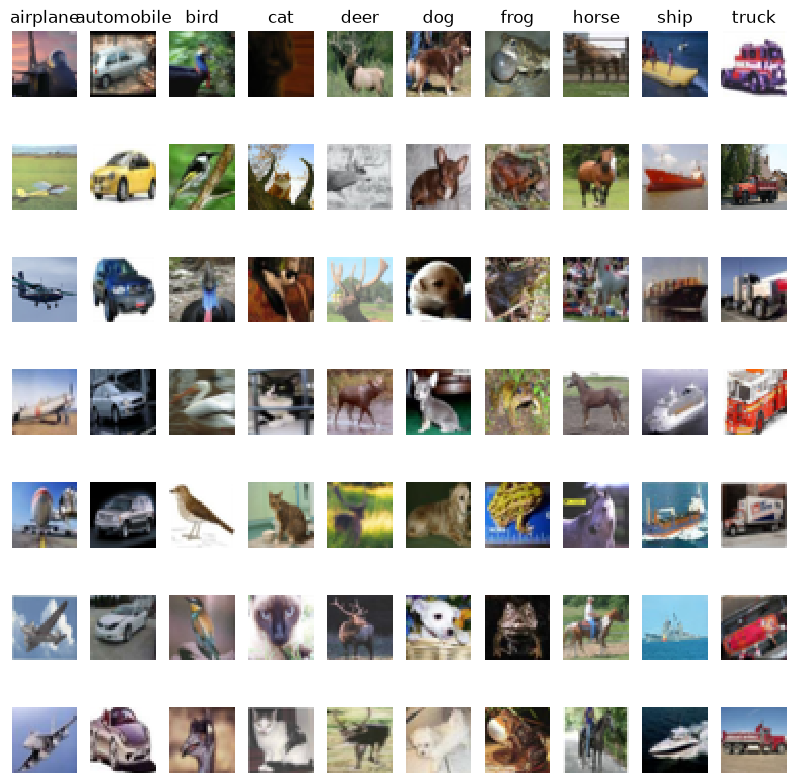

In [91]:
# Now let's visualise some of the images
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes): # y and cls takes values from 0-9
    idxs = np.flatnonzero(y_train == y) # gets the indices of samples that corresponds to class y
    idxs = np.random.choice(idxs, samples_per_class, replace=False) # picks randomly samples_per_class indices
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1   # determines the sub-plot index
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [92]:
# Subsample the data for more efficient code execution in this exercise. We do this to make it go faster.
# When you will have completed the whole notebook, you can run it again on a larger (or total) dataset 
# and observe the difference in terms of accuracy (and speedup).
num_training = 5000
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

num_test = 500
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print("Training data shape: ", X_train.shape)
print("Training labels shape: ", y_train.shape)
print("Test data shape: ", X_test.shape)
print("Test labels shape: ", y_test.shape)

Training data shape:  (5000, 32, 32, 3)
Training labels shape:  (5000,)
Test data shape:  (500, 32, 32, 3)
Test labels shape:  (500,)


In [93]:
# Shape the images vectors
X_train = np.reshape(X_train, (X_train.shape[0], -1)) # when reshaping, -1 means "infer target dims from orig dims
X_test = np.reshape(X_test, (X_test.shape[0], -1))    # in this case it flattens the (32,32,3) into 3072
print(X_train.shape, X_test.shape)

(5000, 3072) (500, 3072)


**Inline Question #2:** Notice the use of np.reshape to transform images into vectors.

- What is the effect of -1 in the reshape command? (1)
- Are the shapes coherent from this vectorization? Explain. (2)

**Your Answer**:
1) np.reshape changes the shape of an array without changing its data, so the total number of elements must stay the same. The "-1" tells Numpy to infer that dimension automatically from the total number of elements and the other given dimensions. Here with (X_train.shape[0],-1)=(5000,-1), the array has 5000x32x32x3 = 15'360'000 elements, so numpy computes 15'360'000/5'000 = 3072. That means each 32x32x3 colour image is flattened into a vector of 3072 values.
2) Yes, X_train goes from (5000,32,32,3) to (5000,3072) and X_test from (500,32,32,3) to (500,3072). The number of images is unchanged and 32x32x3 = 3072, so no pxl value is lost or added. The arrays go from rank 4 to rank 2, where each row is one image as a vector. Compared to (Fashion-)MNIST, each vector is almost 4 times longer (3072 vs 784).

In [94]:
# This is a class definition for our KNN classifier. Complete the code indicated by the TODO sections.
import numpy as np

class KNearestNeighbor(object):
  """ a kNN classifier with L2 distance """

  def __init__(self):
    pass

  def train(self, X, y):
    """
    Train the classifier. For k-nearest neighbors this is just 
    memorizing the training data.

    Inputs:
    - X: A numpy array of shape (num_train, D) containing the training data
      consisting of num_train samples each of dimension D.
    - y: A numpy array of shape (N,) containing the training labels, where
         y[i] is the label for X[i].
    """
    self.X_train = X
    self.y_train = y
    
  def predict(self, X, k=1, num_loops=0):
    """
    Predict labels for test data using this classifier.

    Inputs:
    - X: A numpy array of shape (num_test, D) containing test data consisting
         of num_test samples each of dimension D.
    - k: The number of nearest neighbors that vote for the predicted labels.
    - num_loops: Determines which implementation to use to compute distances
      between training points and testing points.

    Returns:
    - y: A numpy array of shape (num_test,) containing predicted labels for the
      test data, where y[i] is the predicted label for the test point X[i].  
    """
    if num_loops == 0:
      dists = self.compute_distances_no_loops(X)
    elif num_loops == 1:
      dists = self.compute_distances_one_loop(X)
    elif num_loops == 2:
      dists = self.compute_distances_two_loops(X)
    else:
      raise ValueError('Invalid value %d for num_loops' % num_loops)

    return self.predict_labels(dists, k=k)

  def compute_distances_two_loops(self, X):
    """
    Compute the distance between each test point in X and each training point
    in self.X_train using a nested loop over both the training data and the 
    test data.

    Inputs:
    - X: A numpy array of shape (num_test, D) containing test data.

    Returns:
    - dists: A numpy array of shape (num_test, num_train) where dists[i, j]
      is the Euclidean distance between the ith test point and the jth training
      point.
    """
    num_test = X.shape[0]
    num_train = self.X_train.shape[0]
    dists = np.zeros((num_test, num_train))
    for i in range(num_test):
      for j in range(num_train):
        #####################################################################
        # TODO:                                                             #
        # Compute the l2 distance between the ith test point and the jth    #
        # training point, and store the result in dists[i, j]. You should   #
        # not use a loop over dimension.                                    #
        #####################################################################

        #L2 dist = square root of the sum of squared pxl differences (vectorized over the 784 dim)
        dists[i,j] = np.sqrt(np.sum((X[i]-self.X_train[j]) ** 2))
    
        #####################################################################
        #                       END OF YOUR CODE                            #
        #####################################################################
    return dists

  def compute_distances_one_loop(self, X):
    """
    Compute the distance between each test point in X and each training point
    in self.X_train using a single loop over the test data.

    Input / Output: Same as compute_distances_two_loops
    """
    num_test = X.shape[0]
    num_train = self.X_train.shape[0]
    dists = np.zeros((num_test, num_train))
    for i in range(num_test):
      #######################################################################
      # TODO:                                                               #
      # Compute the l2 distance between the ith test point and all training #
      # points, and store the result in dists[i, :].                        #
      #######################################################################

      #Use broadcastingsubtract X[i] from every training img, the sum over pxls
      dists[i,:] = np.sqrt(np.sum((self.X_train - X[i]) ** 2, axis=1))
    
      #######################################################################
      #                         END OF YOUR CODE                            #
      #######################################################################
    return dists

  def compute_distances_no_loops(self, X):
    """
    Compute the distance between each test point in X and each training point
    in self.X_train using no explicit loops.

    Input / Output: Same as compute_distances_two_loops
    """
    num_test = X.shape[0]
    num_train = self.X_train.shape[0]
    dists = np.zeros((num_test, num_train)) 
    #########################################################################
    # TODO:                                                                 #
    # Compute the l2 distance between all test points and all training      #
    # points without using any explicit loops, and store the result in      #
    # dists.                                                                #
    #                                                                       #
    # You should implement this function using only basic array operations; #
    # in particular you should not use functions from scipy.                #
    #                                                                       #
    # HINT: Try to formulate the l2 distance using matrix multiplication    #
    #       and two broadcast sums.                                         #
    #########################################################################

    #use ||x-y||^2 = ||x||^2  + ||y||^2 -2 x.y  (1 mtrx product + 2 broadcast sums

    # ||x||^2 for each test image, shape (num_test,1)
    test_sq = np.sum(X ** 2, axis=1).reshape(-1, 1)

    # ||y||^2 for each train image, shape (1,num_train)
    train_sq = np.sum(self.X_train ** 2, axis=1).reshape(1,-1)

    # x.y for every pair, shape (num_test, num_train
    cross = np.dot(X, self.X_train.T)

    dists = np.sqrt(np.maximum(test_sq + train_sq - 2 * cross,0))



    #########################################################################
    #                         END OF YOUR CODE                              #
    #########################################################################
    return dists

  def predict_labels(self, dists, k=1):
    """
    Given a matrix of distances between test points and training points,
    predict a label for each test point.

    Inputs:
    - dists: A numpy array of shape (num_test, num_train) where dists[i, j]
      gives the distance betwen the ith test point and the jth training point.

    Returns:
    - y: A numpy array of shape (num_test,) containing predicted labels for the
      test data, where y[i] is the predicted label for the test point X[i].  
    """
    num_test = dists.shape[0]
    y_pred = np.zeros(num_test)
    for i in range(num_test):
      # A list of length k storing the labels of the k nearest neighbors to
      # the ith test point.
      closest_y = []
      #########################################################################
      # TODO:                                                                 #
      # Use the distance matrix to find the k nearest neighbors of the ith    #
      # testing point, and use self.y_train to find the labels of these       #
      # neighbors. Store these labels in closest_y.                           #
      # Hint: Look up the function numpy.argsort.                             #
      #########################################################################

      #indics of the k training img with the smallest dist
      nearest_idx = np.argsort(dists[i])[:k]
      closest_y = self.y_train[nearest_idx]
      
      #########################################################################
      # TODO:                                                                 #
      # Now that you have found the labels of the k nearest neighbors, you    #
      # need to find the most common label in the list closest_y of labels.   #
      # Store this label in y_pred[i]. Break ties by choosing the smaller     #
      # label.                                                                #
      #########################################################################

      #count votes per label
      #argmax to return the smallest label in case of a tie
      y_pred[i] = np.argmax(np.bincount(closest_y))
      
      #########################################################################
      #                           END OF YOUR CODE                            # 
      #########################################################################

    return y_pred

In [95]:
# Create a kNN classifier instance. 
# Remember that training a kNN classifier is a noop: 
# the Classifier simply remembers the data and does no further processing 
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

In [96]:
# TODO: implement compute_distances_two_loops from the knn class definition above

# Test your implementation:
dists = classifier.compute_distances_two_loops(X_test)
print(dists.shape)

(500, 5000)


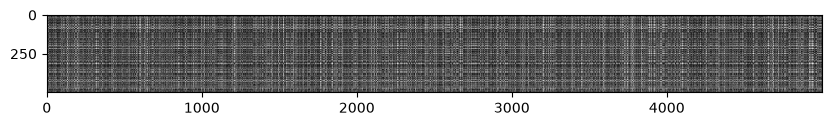

In [97]:
# We can visualize the distance matrix: each row is a single test example and
# its distances to training examples
plt.imshow(dists, interpolation='none')
plt.show()

**Inline Question #3:** Notice the structured patterns in the distance matrix, where some rows or columns are visible brighter. (Note that with the default color scheme black indicates low distances while white indicates high distances.)

- What in the data is the cause behind the distinctly bright rows? (1)
- What causes the bright columns? (2)

**Your Answer**:
1) Each entry dists[i,j] is the L2 distance btw test image i (row) and training image j (column). White means a large distance. A bright row means that the test image is far from almost all training images. On CIFAR-10 this is mainly caused by the global colour/brightness of the image: a test image that is very bright (e.g. a white or light sky background, snow) or very dark, or that has a strong saturated colour, differs from most training images on almost all of its 3072 values, so its distance to nearly every training image is large.
2) A bright column corresponds to a training image that is far from almost all test images, for the same reason: this training image has an atypical overall intensity or colour (very bright, very dark, uniform saturated background) compared to the rest of the dataset.

Conversely, darker rows and columns correspond to images with "average" intensities (medium grey/brown tones), which are close to many images. This shows the limitation of the L2 distance on raw pxls: on natural images it mostly measures the similarity of background colour and brightness at each pxl position, not the object that is in the image. A white airplane on a blue sky and a white ship on a blue sea can be very close, while two cats with different backgrounds are far apart.

In [98]:
# TODO : Now implement the function predict_labels from the KNN class above and run the code below:
# We use k = 1 (which is Nearest Neighbor).
y_test_pred = classifier.predict_labels(dists, k=1)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (int(num_correct), num_test, accuracy))

Got 137 / 500 correct => accuracy: 0.274000


On CIFAR-10 we only get about 27% accuracy (chance level is 10%), far below MNIST and Fashion-MNIST.

In [99]:
y_test_pred = classifier.predict_labels(dists, k=5)
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (int(num_correct), num_test, accuracy))

Got 139 / 500 correct => accuracy: 0.278000


You should expect to see a slightly better performance than with `k = 1`.

In [100]:
# Now lets speed up distance matrix computation by using partial vectorization
# with one loop. Implement the function compute_distances_one_loop and run the
# code below:
dists_one = classifier.compute_distances_one_loop(X_test)

# To ensure that our vectorized implementation is correct, we make sure that it
# agrees with the naive implementation. There are many ways to decide whether
# two matrices are similar; one of the simplest is the Frobenius norm. In case
# you haven't seen it before, the Frobenius norm of two matrices is the square
# root of the squared sum of differences of all elements; in other words, reshape
# the matrices into vectors and compute the Euclidean distance between them.
difference = np.linalg.norm(dists - dists_one, ord='fro')
print('Difference was: %f' % (difference, ))
if difference < 0.001:
  print('Good! The distance matrices are the same')
else:
  print('Uh-oh! The distance matrices are different')

Difference was: 0.000000
Good! The distance matrices are the same


In [101]:
# Now implement the fully vectorized version inside compute_distances_no_loops
# and run the code
dists_two = classifier.compute_distances_no_loops(X_test)

# check that the distance matrix agrees with the one we computed before:
difference = np.linalg.norm(dists - dists_two, ord='fro')
print('Difference was: %f' % (difference, ))
if difference < 0.001:
  print('Good! The distance matrices are the same')
else:
  print('Uh-oh! The distance matrices are different')

Difference was: 0.000000
Good! The distance matrices are the same


In [102]:
# Let's compare how fast the implementations are
def time_function(f, *args):
  """
  Call a function f with args and return the time (in seconds) that it took to execute.
  """
  import time
  tic = time.time()
  f(*args)
  toc = time.time()
  return toc - tic

two_loop_time = time_function(classifier.compute_distances_two_loops, X_test)
print('Two loop version took %f seconds' % two_loop_time)

one_loop_time = time_function(classifier.compute_distances_one_loop, X_test)
print('One loop version took %f seconds' % one_loop_time)

no_loop_time = time_function(classifier.compute_distances_no_loops, X_test)
print('No loop version took %f seconds' % no_loop_time)

# you should see significantly faster performance with the fully vectorized implementation

Two loop version took 18.123721 seconds
One loop version took 39.367141 seconds
No loop version took 0.174298 seconds


### Cross-validation

We have implemented the k-Nearest Neighbor classifier but we set the value k = 5 arbitrarily. We will now determine the best value of this hyperparameter with cross-validation.

In [103]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50]

#X_train_folds = []
#y_train_folds = []
################################################################################
# TODO:                                                                        #
# Split up the training data into folds. After splitting, X_train_folds and    #
# y_train_folds should each be lists of length num_folds, where                #
# y_train_folds[i] is the label vector for the points in X_train_folds[i].     #
# Hint: Look up the numpy array_split function.                                #
################################################################################
X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

################################################################################
#                                 END OF YOUR CODE                             #
################################################################################

# A dictionary holding the accuracies for different values of k that we find
# when running cross-validation. After running cross-validation,
# k_to_accuracies[k] should be a list of length num_folds giving the different
# accuracy values that we found when using that value of k.
k_to_accuracies = {}


################################################################################
# TODO:                                                                        #
# Perform k-fold cross validation to find the best value of k. For each        #
# possible value of k, run the k-nearest-neighbor algorithm num_folds times,   #
# where in each case you use all but one of the folds as training data and the #
# last fold as a validation set. Store the accuracies for all fold and all     #
# values of k in the k_to_accuracies dictionary.                               #
################################################################################
for k in k_choices:
    k_to_accuracies[k] = []
for fold in range(num_folds):
    #current fold is used as validation set
    X_val = X_train_folds[fold]
    y_val = y_train_folds[fold]

    #all other concatenated to form the training set
    X_tr = np.concatenate([X_train_folds[j] for j in range (num_folds) if j!=fold])
    y_tr = np.concatenate([y_train_folds[j] for j in range (num_folds) if j!=fold])

    classifier_cv = KNearestNeighbor()
    classifier_cv.train(X_tr, y_tr)
    dists_cv = classifier_cv.compute_distances_no_loops(X_val)

    for k in k_choices:
        y_val_pred = classifier_cv.predict_labels(dists_cv, k=k)
        accuracy = np.mean(y_val_pred == y_val)
        k_to_accuracies[k].append(accuracy)


################################################################################
#                                 END OF YOUR CODE                             #
################################################################################

# Print out the computed accuracies
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

k = 1, accuracy = 0.263000
k = 1, accuracy = 0.257000
k = 1, accuracy = 0.264000
k = 1, accuracy = 0.278000
k = 1, accuracy = 0.266000
k = 3, accuracy = 0.239000
k = 3, accuracy = 0.249000
k = 3, accuracy = 0.240000
k = 3, accuracy = 0.266000
k = 3, accuracy = 0.254000
k = 5, accuracy = 0.248000
k = 5, accuracy = 0.266000
k = 5, accuracy = 0.280000
k = 5, accuracy = 0.292000
k = 5, accuracy = 0.280000
k = 8, accuracy = 0.262000
k = 8, accuracy = 0.282000
k = 8, accuracy = 0.273000
k = 8, accuracy = 0.290000
k = 8, accuracy = 0.273000
k = 10, accuracy = 0.265000
k = 10, accuracy = 0.296000
k = 10, accuracy = 0.276000
k = 10, accuracy = 0.284000
k = 10, accuracy = 0.280000
k = 12, accuracy = 0.260000
k = 12, accuracy = 0.295000
k = 12, accuracy = 0.279000
k = 12, accuracy = 0.283000
k = 12, accuracy = 0.280000
k = 15, accuracy = 0.252000
k = 15, accuracy = 0.289000
k = 15, accuracy = 0.278000
k = 15, accuracy = 0.282000
k = 15, accuracy = 0.274000
k = 20, accuracy = 0.270000
k = 20, accu

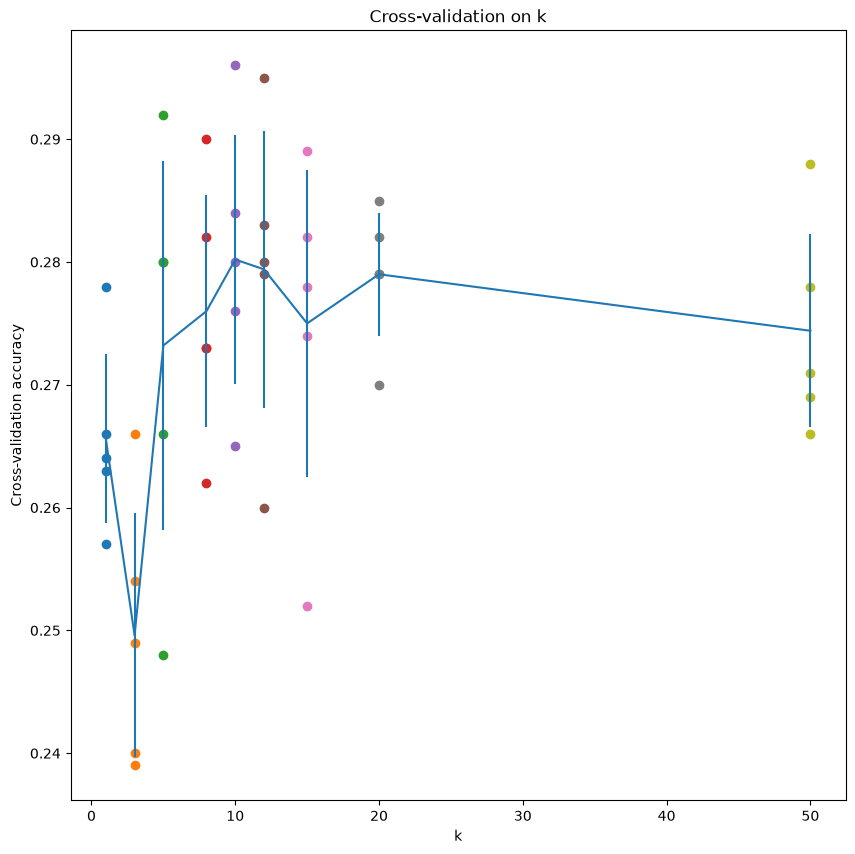

In [104]:
# plot the raw observations
for k in k_choices:
  accuracies = k_to_accuracies[k]
  plt.scatter([k] * len(accuracies), accuracies)

# plot the trend line with error bars that correspond to standard deviation
accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title('Cross-validation on k')
plt.xlabel('k')
plt.ylabel('Cross-validation accuracy')
plt.ylabel('Cross-validation accuracy')
plt.show()

In [105]:
# Based on the cross-validation results above, choose the best value for k,   
# retrain the classifier using all the training data, and test it on the test
# data. You should be able to get above 90% accuracy on the test data.
best_k = 10   # TODO: put your best k value here
             # highest mean cross-validation accuracy (0.282)
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

# Compute and display the accuracy
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (int(num_correct), num_test, accuracy))

Got 141 / 500 correct => accuracy: 0.282000


In [106]:
for c, cls in enumerate(classes):
    mask_c = (y_test == c)
    print('%-10s : %.2f  (%d test images)' % (cls, np.mean(y_test_pred[mask_c] == c), np.sum(mask_c)))

airplane   : 0.49  (57 test images)
automobile : 0.07  (41 test images)
bird       : 0.49  (51 test images)
cat        : 0.14  (49 test images)
deer       : 0.33  (40 test images)
dog        : 0.12  (48 test images)
frog       : 0.20  (54 test images)
horse      : 0.02  (47 test images)
ship       : 0.70  (57 test images)
truck      : 0.12  (56 test images)


## Compare CIFAR-10 to the performances obtained on Fashion-MNIST and digit MNIST.

All three experiments were run with exactly the same setup: 5'000 training images, 500 test images, L2 distance on raw pxls, and 5-fold cross-validation over k {1, 3, 5, 8, 10, 12, 15, 20, 50}.

| | MNIST (digits) | Fashion-MNIST | CIFAR-10 |
|---|---|---|---|
| Image size | 28x28x1 (784) | 28x28x1 (784) | 32x32x3 (3072) |
| Best k (cross-validation) | 1 | 5 | 10 |
| Mean CV accuracy (best k) | 92.9 % | 80.7 % | 28.0 % |
| Test accuracy (best k) | 90.6 % | 81.4 % | 28.2 % |
| Time, two loops | 18.1 s | 13.2 s | 18.1 s |
| Time, one loop | 9.9 s | 14.8 s | 39.4 s |
| Time, no loops | 1.31 s | 1.64 s | 0.17 s |

**Accuracy:** CIFAR-10 is by far the hardest dataset for kNN on raw pxls. With 28.2 % test accuracy, the classifier is well above chance (10 %) but more than 50 points below Fashion-MNIST (81.4 %) and 60 points below MNIST (90.6 %). MNIST and Fashion-MNIST contain centered, size-normalized objects on a uniform black background, so the pxl values directly describe the shape of the object. CIFAR-10 contains natural photos: the object can be anywhere in the image, at any scale, in any pose and colour, and most pxls belong to a varied background (sky, grass, water, road). The L2 distance therefore mostly compares background colour and brightness pxl by pxl, not the object itself: an airplane in the sky and a ship on the sea can be very close, while two cats on different backgrounds are far apart. The per-class accuracies confirm this: the best recognized classes are ship (70 %), airplane (49 %), bird (49 %) and deer (33 %), which typically appear on a uniform background (sea, sky, grass/forest). Classes with cluttered and varied backgrounds, such as horse (2 %), automobile (7 %), dog and truck (12 %) or cat (14 %), are almost never recognized. The classifier thus recognizes the background rather than the object itself.

**Choice of k:** the best k grows with the difficulty of the dataset: k = 1 for MNIST, k = 5 for Fashion-MNIST and k = 10 for CIFAR-10. When classes overlap strongly in pxl space, the single nearest neighbor is often an image of another class, and letting more neighbors vote smooths out these errors. However, on CIFAR-10 all values of k between 5 and 50 give almost the same accuracy (27.3-28.0 %, within one standard deviation): choosing k cannot compensate for a distance that does not capture the content of the image.

**Computation time:**
- *Two loops:* the time is similar for the three datasets (13-18 s) although CIFAR-10 vectors are 4x longer. The cost is dominated by the 2.5 million Python iterations (500 x 5000), not by the vector length. The difference between 13 s and 18 s is mostly due to the variability of the machine load between runs (MNIST and CIFAR-10 both took 18.1 s).
- *One loop:* this is the only version whose time clearly grows with the dimension (9.9 s and 14.8 s for 784 values, 39.4 s for 3072). On CIFAR-10 it is even slower than the two-loop version, because each of the 500 iterations creates a large temporary array of 5000x3072 values, and the computation becomes limited by memory access.
- *No loops:* the fully vectorized version is by far the fastest on all datasets. Surprisingly, it is faster on CIFAR-10 (0.17 s) than on MNIST and Fashion-MNIST (1.3-1.6 s) despite 4x longer vectors. The CIFAR-10 data is converted to float64, so the matrix product uses optimized BLAS routines, whereas the MNIST and Fashion-MNIST data loaded from CSV with pandas are integers (int64), for which numpy has no optimized matrix product.

**Conclusion:** kNN with L2 distance on raw pxls works well for simple centered images (digits), less well when classes differ in fine details (clothing), and poorly on natural images (CIFAR-10). To do better, images must be described by more robust features (histograms, HOG, LBP, or features learned by a neural network) instead of raw pxl values, as explored in part c).